
======= 50% PROJECT OUTPUT =======
GLCM Contrast     : 37.66068052930057
GLCM Homogeneity  : 0.6423980330649928
GLCM Energy       : 0.301361386269536
GLCM Correlation  : 0.9942091172733728

First order statistics
Mean              : 41.800493370336106
Standard deviation: 56.81756925578989
Variance          : 3228.236176136481
Median            : 8.0

LBP features
LBP Mean          : 5.929386370644465
LBP Std           : 2.1025826943792065


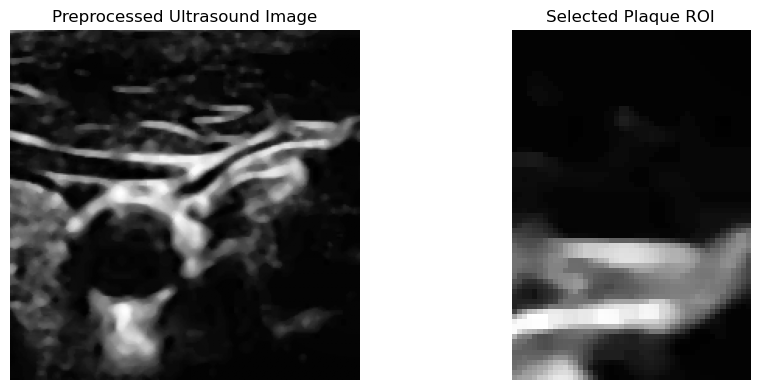

In [1]:
import cv2
import numpy as np
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
import matplotlib.pyplot as plt

# ----------------------------
# Parameters
# ----------------------------
LBP_POINTS = 8
LBP_RADIUS = 1

# Simple rule thresholds (you may tune these)
MEDIAN_THRESHOLD = 80
HOMOGENEITY_THRESHOLD = 0.40

# ----------------------------
# Load image
# ----------------------------
image_path = "sample.jfif"   # change to your ultrasound image
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Image not found.")
    exit()

# ----------------------------
# Preprocessing
# ----------------------------
# Speckle noise reduction
filtered = cv2.medianBlur(img, 5)

# Contrast enhancement using CLAHE
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
enhanced = clahe.apply(filtered)

# ----------------------------
# Manual ROI selection
# ----------------------------
roi = cv2.selectROI("Select Plaque ROI", enhanced, False, False)
cv2.destroyWindow("Select Plaque ROI")

x, y, w, h = roi
plaque_roi = enhanced[y:y+h, x:x+w]

if plaque_roi.size == 0:
    print("Invalid ROI selected.")
    exit()

# ----------------------------
# Texture Feature Extraction
# ----------------------------

# GLCM
glcm = graycomatrix(
    plaque_roi,
    distances=[1],
    angles=[0],
    levels=256,
    symmetric=True,
    normed=True
)

contrast = graycoprops(glcm, 'contrast')[0, 0]
homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
energy = graycoprops(glcm, 'energy')[0, 0]
correlation = graycoprops(glcm, 'correlation')[0, 0]

# First order statistics
mean_val = np.mean(plaque_roi)
std_val = np.std(plaque_roi)
median_val = np.median(plaque_roi)
variance_val = np.var(plaque_roi)

# LBP
lbp = local_binary_pattern(plaque_roi, LBP_POINTS, LBP_RADIUS, method="uniform")
lbp_mean = np.mean(lbp)
lbp_std = np.std(lbp)

# ----------------------------
# Display results (50% output)
# ----------------------------

print("\n======= 50% PROJECT OUTPUT =======")
print("GLCM Contrast     :", contrast)
print("GLCM Homogeneity  :", homogeneity)
print("GLCM Energy       :", energy)
print("GLCM Correlation  :", correlation)

print("\nFirst order statistics")
print("Mean              :", mean_val)
print("Standard deviation:", std_val)
print("Variance          :", variance_val)
print("Median            :", median_val)

print("\nLBP features")
print("LBP Mean          :", lbp_mean)
print("LBP Std           :", lbp_std)

# Show images
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Preprocessed Ultrasound Image")
plt.imshow(enhanced, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Selected Plaque ROI")
plt.imshow(plaque_roi, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()
